In [49]:
#Importing the required packages
import pandas as pd
import numpy as np
import re
import matplotlib.pyplot as plt
import seaborn as sns

In [50]:
#Reading in the files
sales=pd.read_csv("sales_transactions.csv")
store=pd.read_csv("store_info.csv")

In [51]:
#Printing the shape of the files
print("Sales shape:", sales.shape)
print("Store shape:", store.shape)

Sales shape: (3085, 12)
Store shape: (30, 6)


In [52]:
#Checking the first rows of the sales dataset
sales.head()

,transaction_id,store_id,sale_date,product_category,quantity,supplier,region,unit_cost,unit_price,inventory_level,labour_hours,labour_cost
0,T000571,S06,2025-06-27 00:00:00,Sports,2,activepro,East,59.53,121.7,31,2.76,73.19 CAD
1,T000763,S18,2025-02-14 00:00:00,Beauty,2,Glow Works,West,17.62,40.84,10,NaN,119.32
2,T000623,S03,NaN,Electronics,1,NORTHSTAR,North,235.26,308.8,145,4.66,103.05
3,T000827,S27,2025-01-06 00:00:00,Grocery,2,FreshFarm,West,6.41,10.74,14,4.56,125.6
4,T000175,S01,2025-05-06 00:00:00,Electronics,8,NorthStar,East,231.33,289.13,48,5.34,113.35


In [53]:
#Checking the first rows of the store dataset
store.head()

,store_id,region,manager,store_size,store_type,opening_year
0,S01,East,Manager_A,Medium,Street,2020
1,S02,South,Manager_B,Medium,Street,2017
2,S03,North,Manager_C,Large,Street,2020
3,Store-04,E,Manager_D,Large,Street,2009
4,S05,East,Manager_E,Small,Mall,2022


**Part A: Data Cleaning**

In [54]:
#Removing duplicate rows from the sales dataset
dupes_removed=sales.duplicated().sum()
sales=sales.drop_duplicates()
print(f"Duplicate transactions removed: {dupes_removed}")

Duplicate transactions removed: 85


In [55]:
#Cleaning the quantity (removing negatives, zeros, text)
#Convert "two", "unknown" etc to NaN, then make it numeric
sales["quantity"] = pd.to_numeric(sales["quantity"], errors="coerce")

#Remove rows where quantity is missing, zero, or negative
invalid_qty=sales[(sales["quantity"].isna())|(sales["quantity"]<=0)]
qty_removed=len(invalid_qty)
sales=sales[(sales["quantity"] > 0) & (sales["quantity"].notna())]
print(f"Invalid quantity records removed: {qty_removed}")

Invalid quantity records removed: 120


In [56]:
#Clean unit_price by removing the $ and CAD
sales["unit_price"] = (
    sales["unit_price"]
    .astype(str)
    .str.replace("$", "", regex=False)
    .str.replace("CAD", "", regex=False)
    .str.strip()
)
sales["unit_price"] = pd.to_numeric(sales["unit_price"], errors="coerce")

#Clean labour_cost by removing the $ and CAD
sales["labour_cost"] = (
    sales["labour_cost"]
    .astype(str)
    .str.replace("$", "", regex=False)
    .str.replace("CAD", "", regex=False)
    .str.strip()
)
sales["labour_cost"] = pd.to_numeric(sales["labour_cost"], errors="coerce")

#Clean unit_cost by removing the $ and CAD
sales["unit_cost"] = (
    sales["unit_cost"]
    .astype(str)
    .str.replace("$", "", regex=False)
    .str.replace("CAD", "", regex=False)
    .str.strip()
)
# Replace "unknown" text with NaN before converting
sales["unit_cost"] = sales["unit_cost"].replace("unknown", np.nan)
sales["unit_cost"] = pd.to_numeric(sales["unit_cost"], errors="coerce")

# Convert negative inventory levels and labour hours to positive
sales["inventory_level"] = pd.to_numeric(sales["inventory_level"], errors="coerce").abs()
sales["labour_hours"] = pd.to_numeric(sales["labour_hours"], errors="coerce").abs()

#Clean dates
sales["sale_date"] = pd.to_datetime(sales["sale_date"], errors="coerce", format="mixed")

In [57]:
#Standardize the supplier names to make it more uniform
def clean_supplier(x):
    if pd.isna(x):
        return pd.NA
    s = str(x).strip().lower().replace("-", " ").replace("  ", " ")
    supplier_map = {
        "northstar": "NorthStar",
        "north star": "NorthStar",
        "activepro": "ActivePro",
        "active pro": "ActivePro",
        "glowworks": "GlowWorks",
        "glow works": "GlowWorks",
        "freshfarm": "FreshFarm",
        "fresh farm": "FreshFarm",
        "budgetsource": "BudgetSource",
        "budget source": "BudgetSource",
        "stylehub": "StyleHub",
        "style hub": "StyleHub",
    }
    return supplier_map.get(s, x)

sales["supplier"] = sales["supplier"].apply(clean_supplier)
print(sales["supplier"].value_counts())

supplier
NorthStar       654
FreshFarm       591
BudgetSource    463
StyleHub        463
ActivePro       360
GlowWorks       349
Name: count, dtype: int64


In [58]:
#Standardize the product_category names from the sales dataset
def clean_category(x):
    if pd.isna(x):
        return pd.NA
    s = str(x).strip().lower()
    cat_map = {
        "electronics": "Electronics",
        "electronic": "Electronics",
        "sporting goods": "Sports",
        "sports": "Sports",
        "grocery": "Grocery",
        "groceries": "Grocery",
        "food": "Grocery",
        "beauty": "Beauty",
        "cosmetics": "Beauty",
        "apparel": "Apparel",
        "clothing": "Apparel",
        "home": "Home",
        "home goods": "Home",
    }
    return cat_map.get(s, x)

sales["product_category"] = sales["product_category"].apply(clean_category)
print(sales["product_category"].value_counts())

product_category
Electronics    654
Grocery        591
Home           463
Apparel        463
Sports         360
Beauty         349
Name: count, dtype: int64


In [59]:
# Clean store_info IDs and regions
def normalize_store_id(x):
    if pd.isna(x):
        return pd.NA
    s = str(x).strip().lower()
    digits = "".join(re.findall(r"\d+", s))
    if digits == "":
        return pd.NA
    return "S" + digits.zfill(2)

store["store_id_clean"] = store["store_id"].apply(normalize_store_id)
sales["store_id_clean"] = sales["store_id"].apply(normalize_store_id)

def clean_region(x):
    if pd.isna(x):
        return pd.NA
    s = str(x).strip().lower()
    region_map = {
        "east": "East", "e": "East",
        "west": "West", "w": "West",
        "north": "North", "n": "North",
        "south": "South", "s": "South",
    }
    return region_map.get(s, x)

store["region_clean"] = store["region"].apply(clean_region)
print(store[["store_id", "store_id_clean", "region", "region_clean"]])

    store_id store_id_clean  region region_clean
0        S01            S01    East         East
1        S02            S02   South        South
2        S03            S03   North        North
3   Store-04            S04      E          East
4        S05            S05    East         East
5        S06            S06    East         East
6        S07            S07   North        North
7        S08            S08  South         South
8        S09            S09    East         East
9         10            S10   SOUTH        South
10       S11            S11   South        South
11       S12            S12   South        South
12       S13            S13    East         East
13       S14            S14      W          West
14       S15            S15    EAST         East
15       S16            S16   South        South
16       S17            S17   North        North
17       S18            S18      W          West
18        19            S19  South         South
19       S20        

In [60]:
# Force all numeric columns to actually be numeric before calculating
sales["unit_price"] = pd.to_numeric(sales["unit_price"], errors="coerce")
sales["unit_cost"] = pd.to_numeric(sales["unit_cost"], errors="coerce")
sales["quantity"] = pd.to_numeric(sales["quantity"], errors="coerce")

In [61]:
#Reporting the required checkpoints
print(f"1. Duplicate transactions removed: {dupes_removed}")
print(f"2. Invalid quantity records removed: {qty_removed}")
print(f"3. Records remaining after cleaning: {len(sales)}")

# Calculate revenue and profit
sales["revenue"] = sales["quantity"] * sales["unit_price"]
sales["gross_profit"] = (sales["unit_price"] - sales["unit_cost"]) * sales["quantity"]

print(f"4. Total revenue: ${sales['revenue'].sum():,.2f}")
print(f"5. Total gross profit: ${sales['gross_profit'].sum():,.2f}")

1. Duplicate transactions removed: 85
2. Invalid quantity records removed: 120
3. Records remaining after cleaning: 2880
4. Total revenue: $941,694.59
5. Total gross profit: $309,308.93


In [62]:
#Merging and saving 
# Normalize sales store_id too before merging
sales["store_id_clean"] = sales["store_id"].apply(normalize_store_id)

master = sales.merge(
    store[["store_id_clean", "store_size", "store_type", "opening_year", "region_clean"]],
    on="store_id_clean",
    how="left"
)

# Reorder columns so cleaned versions sit next to their originals
master = master[[
    'transaction_id',
    'store_id', 'store_id_clean',
    'sale_date',
    'product_category',
    'quantity',
    'supplier',
    'region', 'region_clean',
    'unit_cost',
    'unit_price',
    'inventory_level',
    'labour_hours',
    'labour_cost',
    'revenue',
    'gross_profit',
    'store_size',
    'store_type',
    'opening_year'
]]

master.to_csv("clean_sales_analysis.csv", index=False)
print("Saved! Final shape:", master.shape)

Saved! Final shape: (2880, 19)


**Part B: Data Analysis and Visualization**

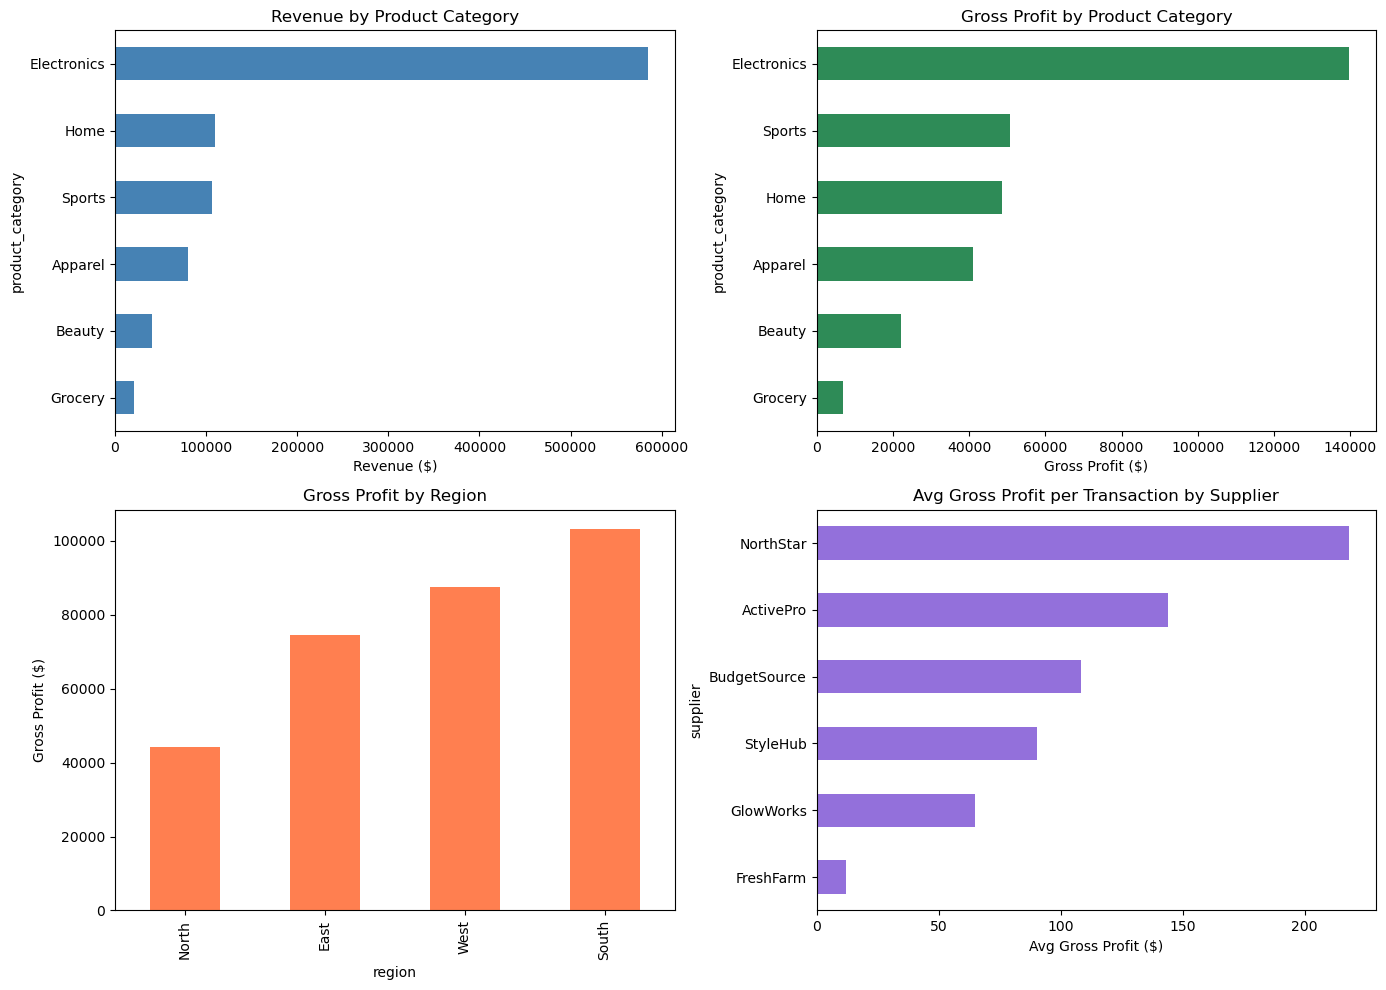

In [63]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# 1. Revenue by category
rev_cat = sales.groupby("product_category")["revenue"].sum().sort_values()
rev_cat.plot(kind="barh", ax=axes[0,0], color="steelblue")
axes[0,0].set_title("Revenue by Product Category")
axes[0,0].set_xlabel("Revenue ($)")

# 2. Gross profit by category
profit_cat = sales.groupby("product_category")["gross_profit"].sum().sort_values()
profit_cat.plot(kind="barh", ax=axes[0,1], color="seagreen")
axes[0,1].set_title("Gross Profit by Product Category")
axes[0,1].set_xlabel("Gross Profit ($)")

# 3. Profit by region
profit_region = sales.groupby("region")["gross_profit"].sum().sort_values()
profit_region.plot(kind="bar", ax=axes[1,0], color="coral")
axes[1,0].set_title("Gross Profit by Region")
axes[1,0].set_ylabel("Gross Profit ($)")

# 4. Supplier performance (avg profit per transaction)
supplier_perf = sales.groupby("supplier")["gross_profit"].mean().sort_values()
supplier_perf.plot(kind="barh", ax=axes[1,1], color="mediumpurple")
axes[1,1].set_title("Avg Gross Profit per Transaction by Supplier")
axes[1,1].set_xlabel("Avg Gross Profit ($)")

plt.tight_layout()
plt.savefig("visualizations.png", dpi=150)
plt.show()

**Consulting Summary and Recommendations to Management**

1. Electronics dominates the revenue, however the profit gap raises concern

The revenue graph shows that Electronics outspaces every category largely; it is around 5 to 6 times larger than the next closest category (Home and Sports). However, when looking at the gross profit graph, the gap between Electronics and other categories narrows considerably. This suggests that Electronics has a thinner profit margin in relativity to its sales volume. ShopSmart is heavily dependent on one category to drive revenue, and this is a business risk.

Recommendation: Diversify revenue streams by promoting higher margin categories. 


2. Grocery generates little to no profit despite there being transactions

In both of the graphs, Grocery has the smallest bar by a significant margin; it is nearly flat in comparison to the other categories. This means that the Grocery category contributes little to no business relative to the costs it likely requires, such as from labour, inventory, and shelf space.

Recommendation:
Evaluate whether the Grocery category is worth maintaining. If the costs outweigh the profit contribution, then consider lowering its footprint or changing it with higher-margin profits.


3. North region significantly lags in gross profit, while South region leads

The regional profit graph shows a clear ranking of South being the strongest performer, followed by the West, then East, with North creating less than half of the gross profit of the South. This shows a lack of balance.

Recommendation:
Investigate why North is underperforming. This may be due to factors such as store locations, staffing, or low demand from customers. Strategies from the South region should be studied and applied to the North.


4. FreshFarm is an outlier in supplier performance

The supplier graph shows that FreshFarm's average gross profit per transaction is much lower than the other suppliers. Every other supplier performs somewhat close to one another, which makes FreshFarm stand out as a problem area.

Recommendation:
Renegotiate FreshFarm's pricing terms or find an alternative grocery supplier.

<br>

**Summary of actions for leadership to improve business performance:**

Electronics & Supplier Costs
- Renegotiate pricing terms with NorthStar to improve Electronics profit margins
- Reduce over-reliance on Electronics as the primary driver for revenue, and develop a diversification strategy so the business is not reliant on mainly Electronics

Grocery and FreshFarm
- Renegotiate contract terms with FreshFarm supplier
- Evaluate whether the Grocery category should be reduced or eliminated given its minimal profit contribution

Regional Performance
- Conduct a full operational review of North region stores to find root causes of its underperformance
- Apply successful strategies from the South region to the East and North
